In [1]:
import pandas as pd
import sys
import os
import jax
from arviz.labels import MapLabeller

sys.path.append(os.path.abspath(os.path.join('../..')))

from utils.modeling import (
    encode_categorical_covariates, 
    fit_model_and_extract_idata,
    )

from utils.plotting import (
    plot_predictive_distributions,
    plot_model_comparison,
    plot_combined_figure
)

/home/ubuntu/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get data

In [2]:
df = pd.read_csv('data.csv')

# Check
print('Unique graders:', set(df['grader']))
print('Unique models:', set(df['LLM']))
df.head(5)

Unique graders: {'Autograder B', 'Autograder A', 'Human'}
Unique models: {'LLM A', 'LLM B'}


,score,grader,LLM
0,8,Human,LLM A
1,7,Human,LLM A
2,5,Human,LLM A
3,6,Human,LLM A
4,8,Human,LLM A


# Fit model

In [3]:
# Define covariates and outcome
main_effects = ['grader', 'LLM']  # categorical variables
interactions = [('grader', 'LLM')]
outcome = 'score'  # ordinal variable, 0–10

# Encode categorical covariates
covariates_dict, category_maps = encode_categorical_covariates(df, main_effects)

# Encore the outcome
allowed_scores = list(range(11))  # ordinal values: 0–10
score_map = {val: i for i, val in enumerate(allowed_scores)}
y = df[outcome].map(score_map).values

# Fit models
rng_key = jax.random.PRNGKey(0)

## Model with interaction
mcmc_with_interaction, idata_with_interaction = fit_model_and_extract_idata(
    rng_key, covariates_dict, y, main_effects, interactions, category_maps
)

## Model without interaction
mcmc_without_interaction, idata_without_interaction =  fit_model_and_extract_idata(
    rng_key, covariates_dict, y, main_effects, interactions=None, category_maps=category_maps
)

sample: 100%|██████████| 2000/2000 [00:06<00:00, 325.46it/s, 15 steps of size 1.65e-01. acc. prob=0.92]


# Compare models

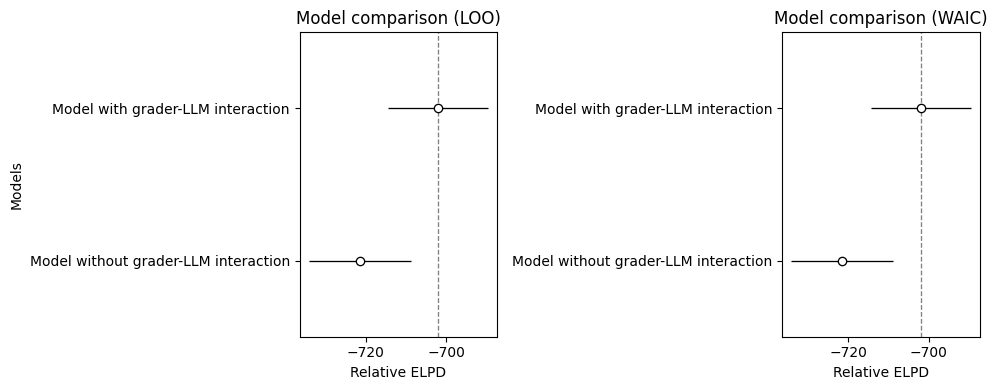

In [4]:
idata_dict = {
    "Model with grader-LLM interaction": idata_with_interaction,
    "Model without grader-LLM interaction": idata_without_interaction
}

plot_model_comparison(idata_dict, ylabel="Models", fig_path="../../figures/figure3c.png")


# Fitted parameters

In [5]:
mcmc_with_interaction.print_summary()


                                 mean       std    median      5.0%     95.0%     n_eff     r_hat
                   b_LLM[0]      1.63      0.39      1.63      1.06      2.31    475.53      1.00
                b_grader[0]     -1.36      0.50     -1.34     -2.14     -0.51    425.21      1.00
                b_grader[1]     -1.48      0.50     -1.48     -2.23     -0.61    423.52      1.00
b_interaction_grader_LLM[0]      1.06      0.78      1.05     -0.17      2.38    440.58      1.00
b_interaction_grader_LLM[1]     -0.79      0.73     -0.80     -2.06      0.30    524.66      1.00
b_interaction_grader_LLM[2]     -0.10      0.75     -0.11     -1.27      1.11    375.95      1.00
b_interaction_grader_LLM[3]      0.28      0.75      0.29     -0.94      1.52    417.38      1.00
b_interaction_grader_LLM[4]      0.93      0.76      0.91     -0.31      2.21    578.13      1.00
b_interaction_grader_LLM[5]      0.72      0.76      0.70     -0.59      1.93    608.67      1.00
          cutpoint_

## Checks

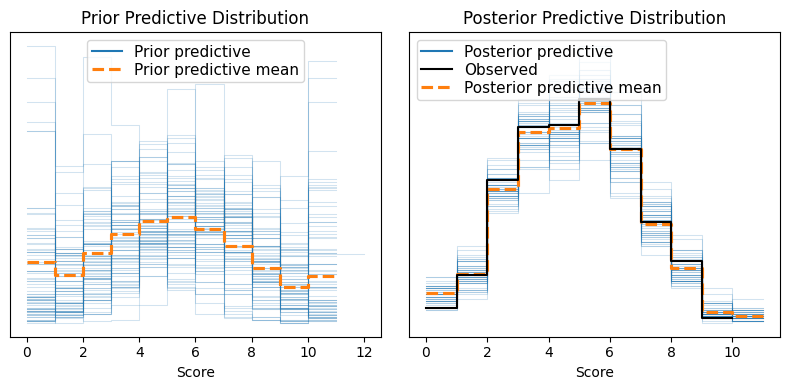

In [6]:
plot_predictive_distributions(idata_with_interaction, fig_path="fig_predictive.png")

# Figure

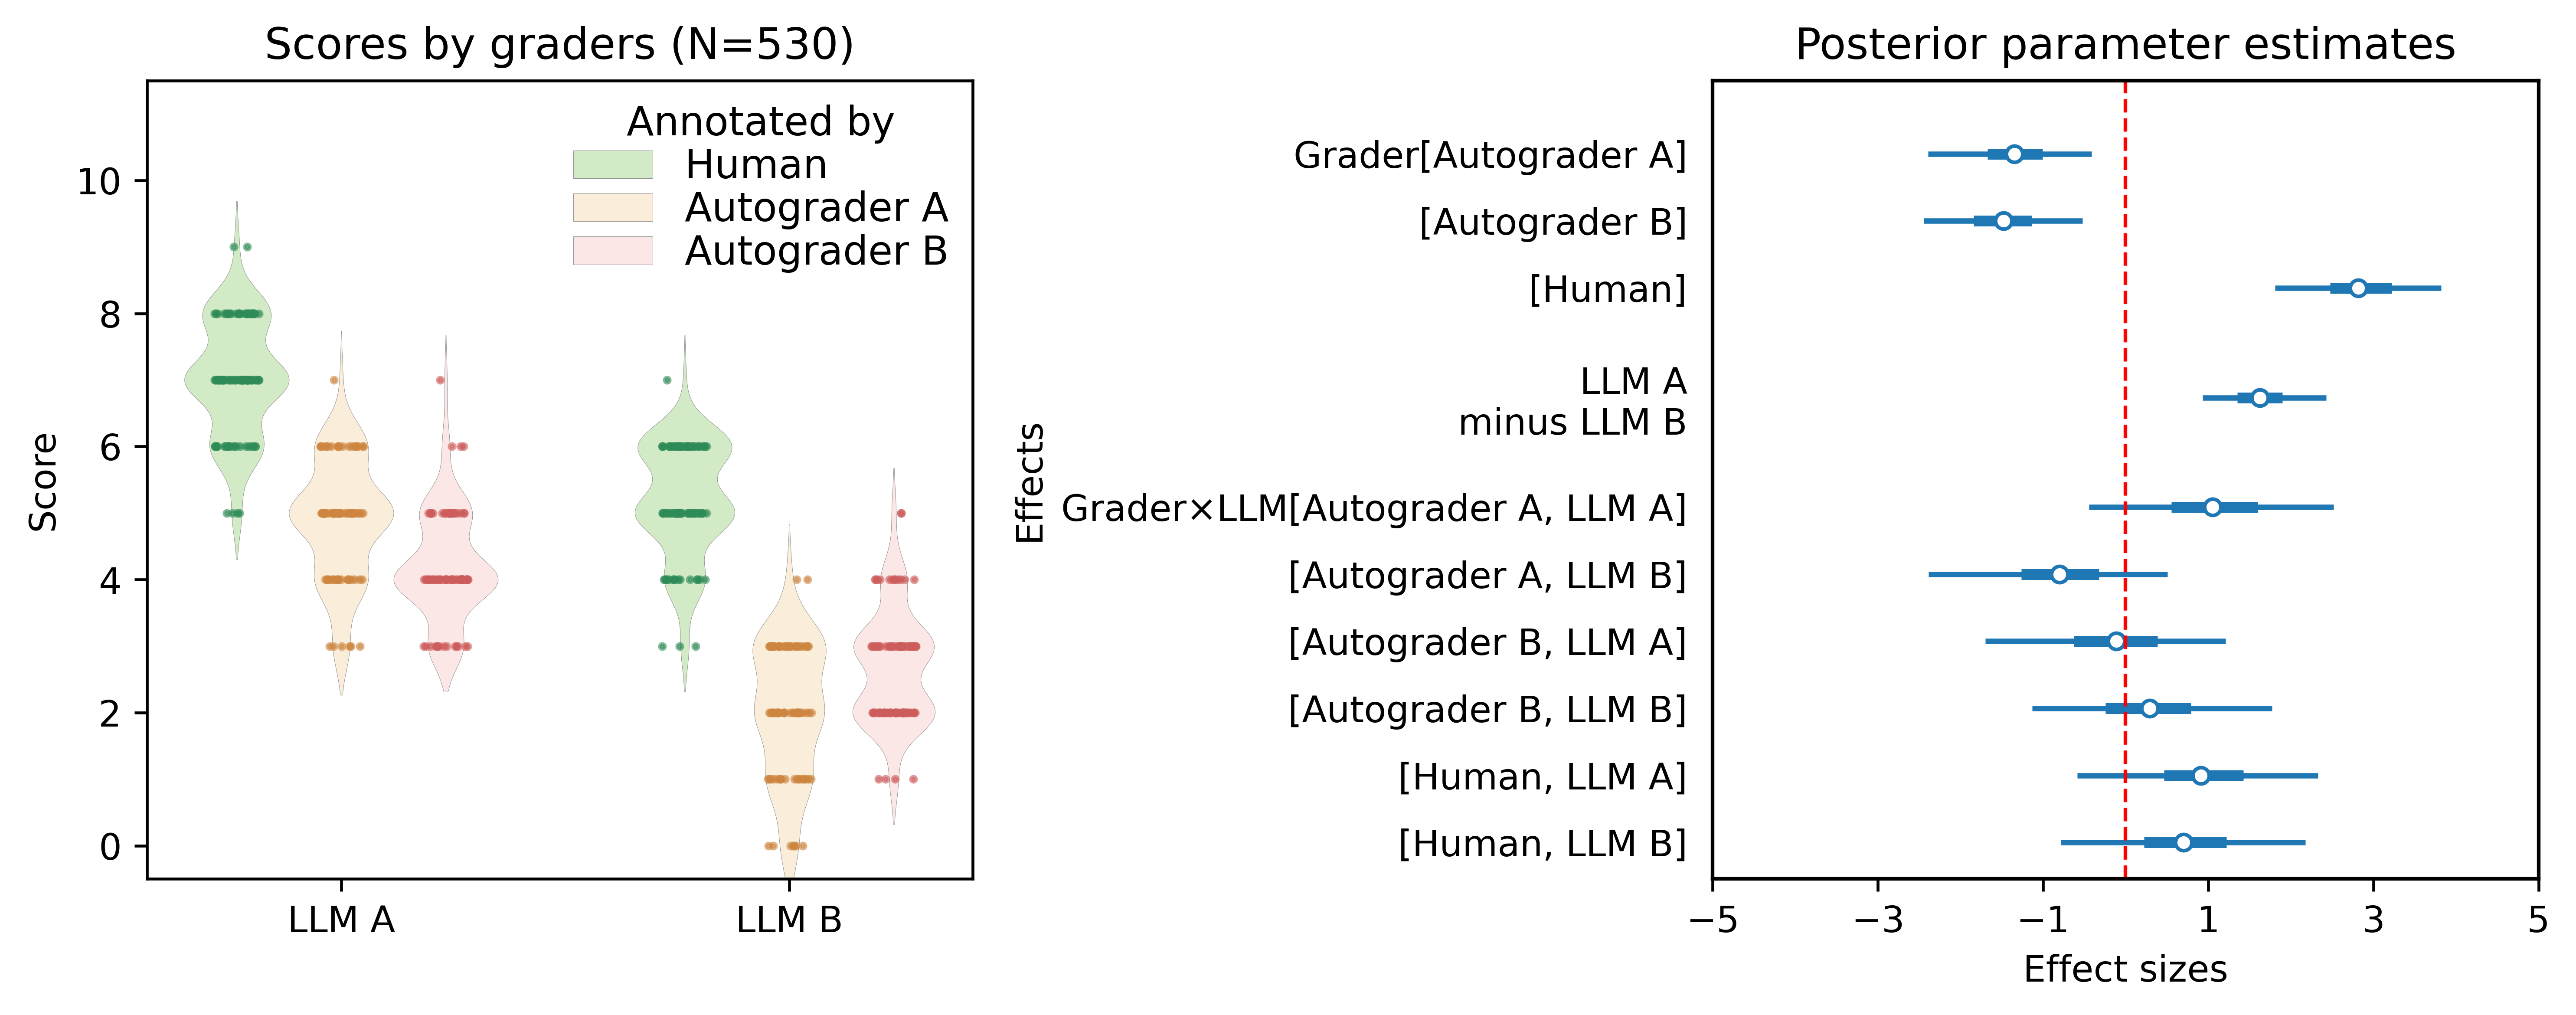

In [ ]:
labeller = MapLabeller(
        var_name_map={
            "b_grader_full": "Grader",
            "b_LLM": "LLM A\nminus LLM B",  
            "b_interaction_grader_LLM_full": "Grader×LLM"
        }
    )

plot_combined_figure(
    df=df,
    idata=idata_with_interaction,
    var_names=[
        "b_grader_full",
        "b_LLM",
        "b_interaction_grader_LLM_full"
    ],
    labeller=labeller,
    color_scheme='2autograders',
    x_var='LLM',
    x_label=None,
    dodge=True,
    fig_path="../../figures/figure3.png",
    legend_title='Annotated by',
    xlim=[-5.0, 5.0],
    show_predictions=False,
    category_maps=category_maps,
    jitter_strength=0.1  
)